# Prompt Strategy Comparison — All Models

Compares batch and whole-document prompting across three models on all 10 DMP samples.

## Experiment setup

**Task:** Label PDF text blocks with one of five labels:
`title` · `section.title` · `section.description` · `question.text` · `answer.text`

**Key challenge:** Distinguishing `question.text` (funder requirement items) from
`section.description` (funder context text). Both are funder-written multi-line text;
the boundary is structural, not lexical.

## Prompt strategies

| Strategy | Context per API call | Calls per document |
|---|---|---|
| Batch | 10 blocks + 3-block sliding context | approximately total blocks / 7 |
| Whole-doc | Full document | 1 |

## Models

| Model | Provider | Batch tag | Whole-doc tag |
|---|---|---|---|
| llama3.3:70b | Ollama | `llama3.3-70b_batch` | `llama3.3-70b_whole_doc` |
| llama3.1:8b | Ollama | `llama3.1-8b_batch` | `llama3.1-8b_whole_doc` |
| claude-opus-4-8 | Anthropic | `claude-opus-4-8_batch` | `claude-opus-4-8_whole_doc` |

## Sections

1. Availability
2. Overall accuracy (per-sample table with batch/whole-doc delta)
3. Per-sample accuracy (bar chart and heatmap)
4. F1 per label
5. Prompt strategy delta (batch to whole-doc, per model)
6. Block-level analysis (which blocks changed and why)
7. Cross-model agreement (how many variants agree on each block)
8. Error drill-down (filterable block-level inspector)
9. Summary


In [1]:
import sys, json
sys.path.insert(0, "../..")

from evaluate import extract_gold, evaluate_sample, match, LABELS, SHORT, LLM_DIR, MANUAL_DIR
from collections import defaultdict
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

sns.set_theme(style="ticks", palette="muted")
plt.rcParams.update({
    "figure.facecolor": "white",  "axes.facecolor": "white",
    "axes.edgecolor":   "#555",   "axes.linewidth": 0.8,
    "grid.color":       "#ddd",   "grid.linewidth": 0.5,
    "text.color":       "#111",   "axes.labelcolor": "#111",
    "xtick.color":      "#111",   "ytick.color": "#111",
    "font.size": 11,  "axes.titlesize": 13,  "axes.labelsize": 11,
    "xtick.labelsize": 10,        "ytick.labelsize": 10,
    "legend.fontsize": 10,        "legend.frameon": True,
    "figure.dpi": 120,
})

# File tags match data/llmlabeled/sampleN_{tag}.json
# Dark shade = batch (solid bar), light shade = whole-doc (hatched bar)
MODEL_FAMILIES = {
    "llama3.3:70b": {
        "batch":     {"tag": "llama3.3-70b_batch",     "color": "#1d4ed8", "hatch": None},
        "whole-doc": {"tag": "llama3.3-70b_whole_doc", "color": "#60a5fa", "hatch": "//"},
    },
    "llama3.1:8b": {
        "batch":     {"tag": "llama3.1-8b_batch",      "color": "#0369a1", "hatch": None},
        "whole-doc": {"tag": "llama3.1-8b_whole_doc",  "color": "#38bdf8", "hatch": "//"},
    },
    "claude-opus-4-8": {
        "batch":     {"tag": "claude-opus-4-8_batch",     "color": "#7c3aed", "hatch": None},
        "whole-doc": {"tag": "claude-opus-4-8_whole_doc", "color": "#c084fc", "hatch": "//"},
    },
}

VARIANTS = {}
for _mname, _methods in MODEL_FAMILIES.items():
    for _method, _cfg in _methods.items():
        VARIANTS[f"{_mname} {_method}"] = _cfg

def _snum(p):
    stem = p.stem if hasattr(p, "stem") else str(p)
    return int(stem.replace("_dmp", "").replace("sample", ""))

SAMPLES = sorted(MANUAL_DIR.glob("*_dmp.json"), key=_snum)
SNAMES  = [mp.stem.replace("_dmp", "") for mp in SAMPLES]

def _f1(conf, lbl):
    tp = conf.get(lbl, {}).get(lbl, 0)
    fp = sum(conf.get(o, {}).get(lbl, 0) for o in LABELS if o != lbl)
    fn = sum(v for p, v in conf.get(lbl, {}).items() if p != lbl)
    p_ = tp / (tp + fp) if (tp + fp) else 0.
    r_ = tp / (tp + fn) if (tp + fn) else 0.
    return 2 * p_ * r_ / (p_ + r_) if (p_ + r_) else 0.

def load_variant(tag):
    rows, conf = [], defaultdict(lambda: defaultdict(int))
    for mp in SAMPLES:
        stem = mp.stem.replace("_dmp", "")
        pp   = LLM_DIR / f"{stem}_{tag}.json"
        if not pp.exists(): continue
        gold = extract_gold(mp)
        c    = evaluate_sample(pp, gold)
        for tl, preds in c.items():
            for pl, cnt in preds.items():
                conf[tl][pl] += cnt
        tp = sum(c.get(l, {}).get(l, 0) for l in LABELS)
        n  = sum(sum(v.values()) for v in c.values())
        rows.append({"sample": stem, "total": n, "correct": tp,
                     "errors": n - tp, "accuracy": tp / n if n else 0})
    return (pd.DataFrame(rows), conf) if rows else (None, None)

DATA   = {name: load_variant(cfg["tag"]) for name, cfg in VARIANTS.items()}
ACTIVE = {n: d for n, d in DATA.items() if d[0] is not None}
n_v    = len(ACTIVE)
print(f"Loaded {n_v} / {len(VARIANTS)} variants.")


Loaded 6 / 6 variants.


---
## Section 1 — Availability

Confirms which variants have complete data across all 10 samples.

In [2]:
print(f"  {'Variant':<30}  {'Status':>12}  {'Samples':>7}  {'Correct':>7}  {'Total':>6}  {'Accuracy':>9}")
print("  " + "-" * 79)
for name, cfg in VARIANTS.items():
    df, _ = DATA[name]
    if df is None:
        print(f"  {name:<30}  {'missing':>12}  {'--':>7}  {'--':>7}  {'--':>6}  {'--':>9}")
    else:
        tc, tn = int(df["correct"].sum()), int(df["total"].sum())
        n_s    = len(df)
        status = "OK" if n_s == 10 else f"partial ({n_s}/10)"
        print(f"  {name:<30}  {status:>12}  {n_s:>7}  {tc:>7}  {tn:>6}  {tc/tn*100:>8.1f}%")


  Variant                               Status  Samples  Correct   Total   Accuracy
  -------------------------------------------------------------------------------
  llama3.3:70b batch                        OK       10      697     741      94.1%
  llama3.3:70b whole-doc                    OK       10      680     741      91.8%
  llama3.1:8b batch                         OK       10      499     741      67.3%
  llama3.1:8b whole-doc                     OK       10      624     741      84.2%
  claude-opus-4-8 batch                     OK       10      703     741      94.9%
  claude-opus-4-8 whole-doc                 OK       10      718     741      96.9%


---
## Section 2 — Overall accuracy

Per-sample block-level accuracy for every variant, with delta columns showing the
accuracy change from switching to whole-doc within the same model family.
Positive delta = whole-doc better; negative delta = batch better.

In [3]:
rows = []
for sname in SNAMES:
    row = {"sample": sname}
    for vname, (df, _) in ACTIVE.items():
        sub = df[df["sample"] == sname]
        row[vname] = sub["accuracy"].values[0] * 100 if len(sub) else None
    rows.append(row)
tbl = pd.DataFrame(rows).set_index("sample")

for mname in MODEL_FAMILIES:
    bcol = f"{mname} batch"
    wcol = f"{mname} whole-doc"
    if bcol in tbl.columns and wcol in tbl.columns:
        tbl[f"d({mname.split(':')[0]})"] = tbl[wcol] - tbl[bcol]

active_cols = list(ACTIVE.keys())
delta_cols  = [c for c in tbl.columns if c.startswith("d(")]
all_cols    = active_cols + delta_cols

def _fmt_val(v, w):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return f"  {'--':>{w}}"
    return f"  {v:>{w-1}.1f}%"

def _fmt_delta(d, w):
    if d is None or (isinstance(d, float) and np.isnan(d)):
        return f"  {'--':>{w}}"
    return f"  {'+' if d >= 0 else ''}{d:>{w-2}.1f}%"

col_w = 16
print(f"  {'Sample':<11}" + "".join(f"  {c:>{col_w}}" for c in all_cols))
print("  " + "-" * (11 + (col_w + 2) * len(all_cols)))
for sname, r in tbl.iterrows():
    line = f"  {sname:<11}"
    for c in active_cols:
        line += _fmt_val(r.get(c), col_w)
    for c in delta_cols:
        line += _fmt_delta(r.get(c), col_w)
    print(line)
print("  " + "-" * (11 + (col_w + 2) * len(all_cols)))

total_line = f"  {'OVERALL':<11}"
for vname in active_cols:
    df, _ = ACTIVE[vname]
    total_line += f"  {df['correct'].sum()/df['total'].sum()*100:>{col_w-1}.1f}%"

for mname in MODEL_FAMILIES:
    bcol = f"{mname} batch"
    wcol = f"{mname} whole-doc"
    key  = f"d({mname.split(':')[0]})"
    if key not in delta_cols:
        continue
    if bcol in ACTIVE and wcol in ACTIVE:
        df_b_ = ACTIVE[bcol][0]
        df_w_ = ACTIVE[wcol][0]
        common = set(df_b_["sample"]) & set(df_w_["sample"])
        if common:
            cb  = df_b_[df_b_["sample"].isin(common)]["correct"].sum()
            cw  = df_w_[df_w_["sample"].isin(common)]["correct"].sum()
            tot = df_b_[df_b_["sample"].isin(common)]["total"].sum()
            d   = (cw - cb) / tot * 100
            note = f"({len(common)}/10)" if len(common) < 10 else ""
            total_line += f"  {'+' if d >= 0 else ''}{d:>{col_w-2}.1f}%{note}"
        else:
            total_line += f"  {'--':>{col_w}}"
    else:
        total_line += f"  {'--':>{col_w}}"
print(total_line)


  Sample       llama3.3:70b batch  llama3.3:70b whole-doc  llama3.1:8b batch  llama3.1:8b whole-doc  claude-opus-4-8 batch  claude-opus-4-8 whole-doc       d(llama3.3)       d(llama3.1)  d(claude-opus-4-8)
  -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  sample1                 97.4%             98.7%             82.1%             93.6%            100.0%            100.0%  +           1.3%  +          11.5%  +           0.0%
  sample2                 90.7%             79.1%             59.9%             86.6%             86.6%             96.5%           -11.6%  +          26.7%  +           9.9%
  sample3                 98.6%            100.0%             81.2%             88.4%            100.0%            100.0%  +           1.4%  +           7.2%  +           0.0%
  sample4                100.0%            100.0%             65.4%             67.9%      

---
## Section 3 — Per-sample accuracy

Solid bars = batch, hatched bars = whole-doc.
Samples where batch and whole-doc diverge sharply indicate documents where
full-document structural context changes the model's behaviour.

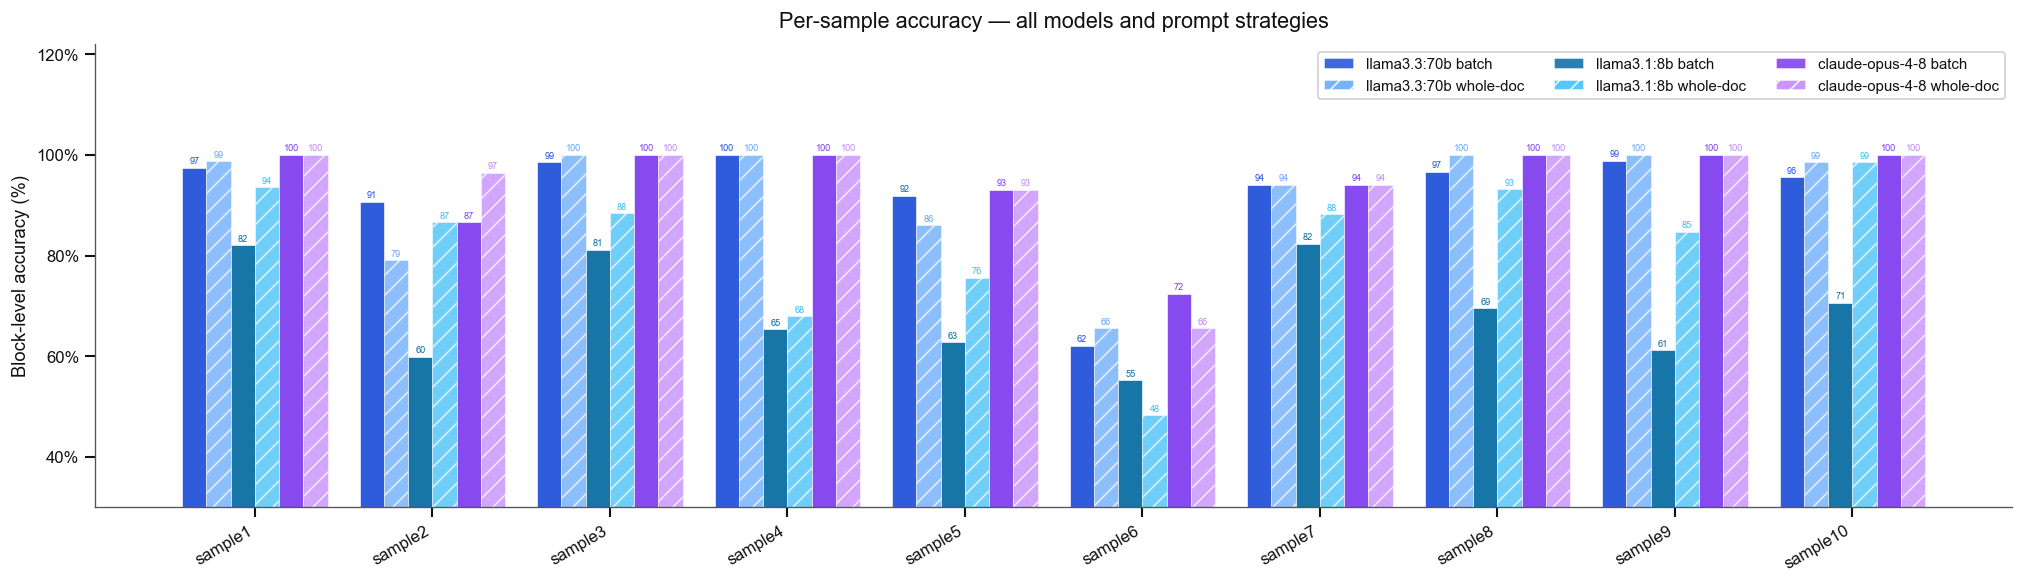

In [4]:
w   = 0.82 / n_v
x   = list(range(len(SNAMES)))
fig, ax = plt.subplots(figsize=(17, 5))

for i, (name, (df, _)) in enumerate(ACTIVE.items()):
    cfg    = VARIANTS[name]
    alpha  = 0.92 if cfg["hatch"] is None else 0.72
    vals   = [
        df[df["sample"] == s]["accuracy"].values[0] * 100
        if len(df[df["sample"] == s]) else 0
        for s in SNAMES
    ]
    offset = (i - n_v / 2 + 0.5) * w
    bars   = ax.bar([xi + offset for xi in x], vals,
                    width=w, label=name, color=cfg["color"],
                    edgecolor="white", linewidth=0.4,
                    alpha=alpha, hatch=cfg["hatch"])
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                    f"{v:.0f}", ha="center", va="bottom",
                    fontsize=5.5, color=cfg["color"])

ax.set_xticks(x)
ax.set_xticklabels(SNAMES, rotation=30, ha="right")
ax.set_ylim(30, 122)
ax.set_ylabel("Block-level accuracy (%)")
ax.set_title("Per-sample accuracy — all models and prompt strategies", pad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))

handles = []
for mname, methods in MODEL_FAMILIES.items():
    for method, cfg in methods.items():
        vname = f"{mname} {method}"
        if vname in ACTIVE:
            handles.append(mpatches.Patch(
                facecolor=cfg["color"], hatch=cfg["hatch"],
                edgecolor="white", label=vname, alpha=0.85))

ax.legend(handles=handles, framealpha=0.9, ncol=3, loc="upper right", fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


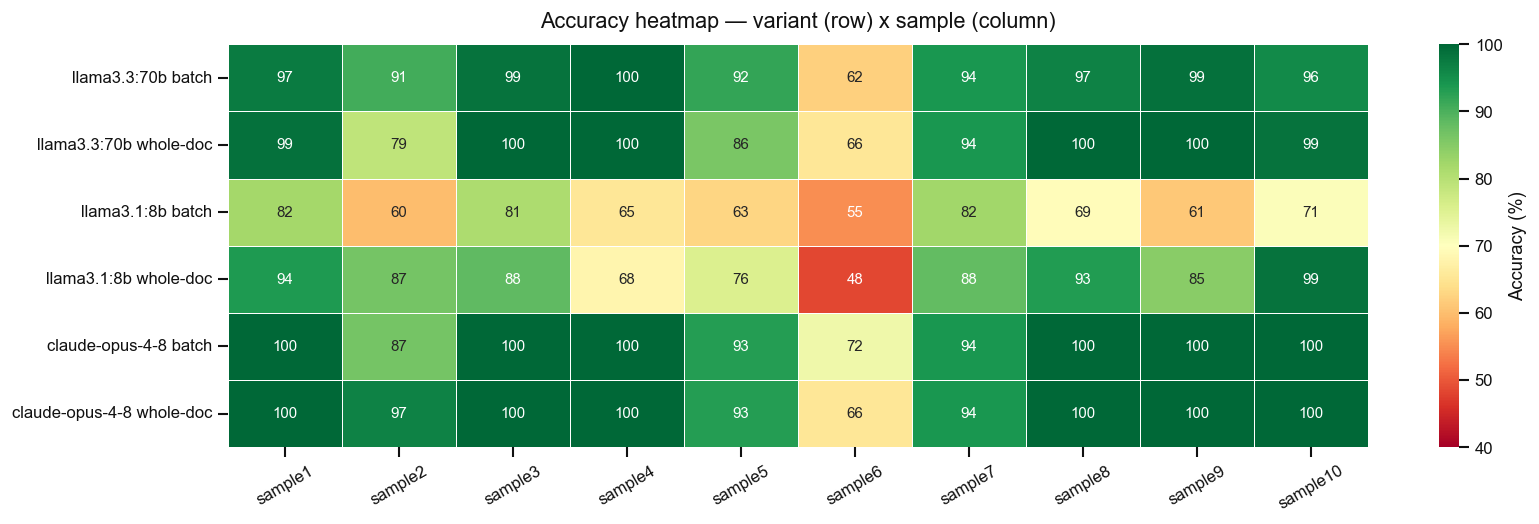

In [5]:
hmap_data = []
for name, (df, _) in ACTIVE.items():
    row = [
        df[df["sample"] == s]["accuracy"].values[0] * 100
        if len(df[df["sample"] == s]) else np.nan
        for s in SNAMES
    ]
    hmap_data.append(row)

hmap_df = pd.DataFrame(hmap_data, index=list(ACTIVE.keys()), columns=SNAMES)

fig, ax = plt.subplots(figsize=(14, max(3, n_v * 0.75)))
sns.heatmap(hmap_df, annot=True, fmt=".0f", cmap="RdYlGn",
            vmin=40, vmax=100, linewidths=0.5, linecolor="white",
            ax=ax, cbar_kws={"label": "Accuracy (%)"},
            annot_kws={"size": 9})
ax.set_title("Accuracy heatmap — variant (row) x sample (column)", pad=10)
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()


---
## Section 4 — F1 per label

F1 is computed over all 10 samples combined (micro-average per label).
The two hardest labels are `question.text` and `section.description` — both are
funder-written text and the model must distinguish them by structural position.

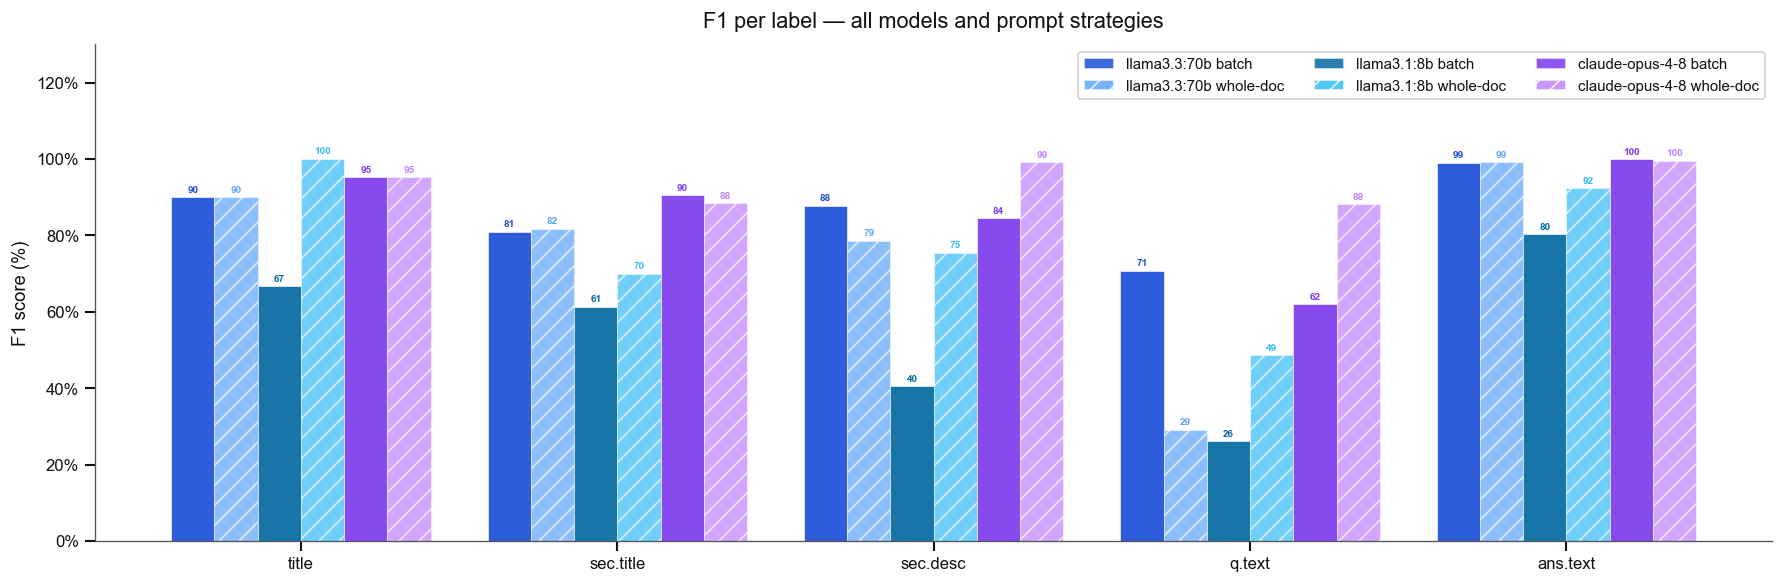


  Label                       llama3.3:70b batch  llama3.3:70b whole-doc       llama3.1:8b batch   llama3.1:8b whole-doc   claude-opus-4-8 batch  claude-opus-4-8 whole-doc
  ----------------------------------------------------------------------------------------------------------------------------------------------------------------------
  title                                    90.0%                   90.0%                   66.7%                  100.0%                   95.2%                   95.2%
  section.title                            80.9%                   81.7%                   61.3%                   70.0%                   90.5%                   88.4%
  section.description                      87.7%                   78.6%                   40.5%                   75.4%                   84.4%                   99.1%
  question.text                            70.7%                   29.0%                   26.1%                   48.6%                   62.0%       

In [6]:
x2 = list(range(len(LABELS)))
w2 = 0.82 / n_v
fig, ax = plt.subplots(figsize=(15, 5))

for i, (name, (_, conf)) in enumerate(ACTIVE.items()):
    cfg    = VARIANTS[name]
    alpha  = 0.92 if cfg["hatch"] is None else 0.72
    f1_vals = [_f1(conf, l) * 100 for l in LABELS]
    offset  = (i - n_v / 2 + 0.5) * w2
    bars    = ax.bar([xi + offset for xi in x2], f1_vals,
                     width=w2, label=name, color=cfg["color"],
                     edgecolor="white", linewidth=0.4,
                     alpha=alpha, hatch=cfg["hatch"])
    for bar, v in zip(bars, f1_vals):
        if v > 2:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                    f"{v:.0f}", ha="center", va="bottom",
                    fontsize=6, fontweight="bold", color=cfg["color"])

ax.set_xticks(x2)
ax.set_xticklabels(SHORT, fontsize=10)
ax.set_ylim(0, 130)
ax.set_ylabel("F1 score (%)")
ax.set_title("F1 per label — all models and prompt strategies", pad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.legend(handles=handles, framealpha=0.9, ncol=3, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

col_w = 22
print(f"\n  {'Label':<22}" + "".join(f"  {n:>{col_w}}" for n in ACTIVE))
print("  " + "-" * (22 + (col_w + 2) * n_v))
for lbl in LABELS:
    row = f"  {lbl:<22}"
    for name, (_, conf) in ACTIVE.items():
        row += f"  {_f1(conf, lbl)*100:>{col_w-1}.1f}%"
    print(row)


---
## Section 5 — Prompt strategy delta (batch to whole-doc)

For each model family that has both strategies, shows:
- Left panel: per-sample accuracy delta (green = whole-doc better, red = batch better)
- Right panel: net blocks gained or lost across all samples

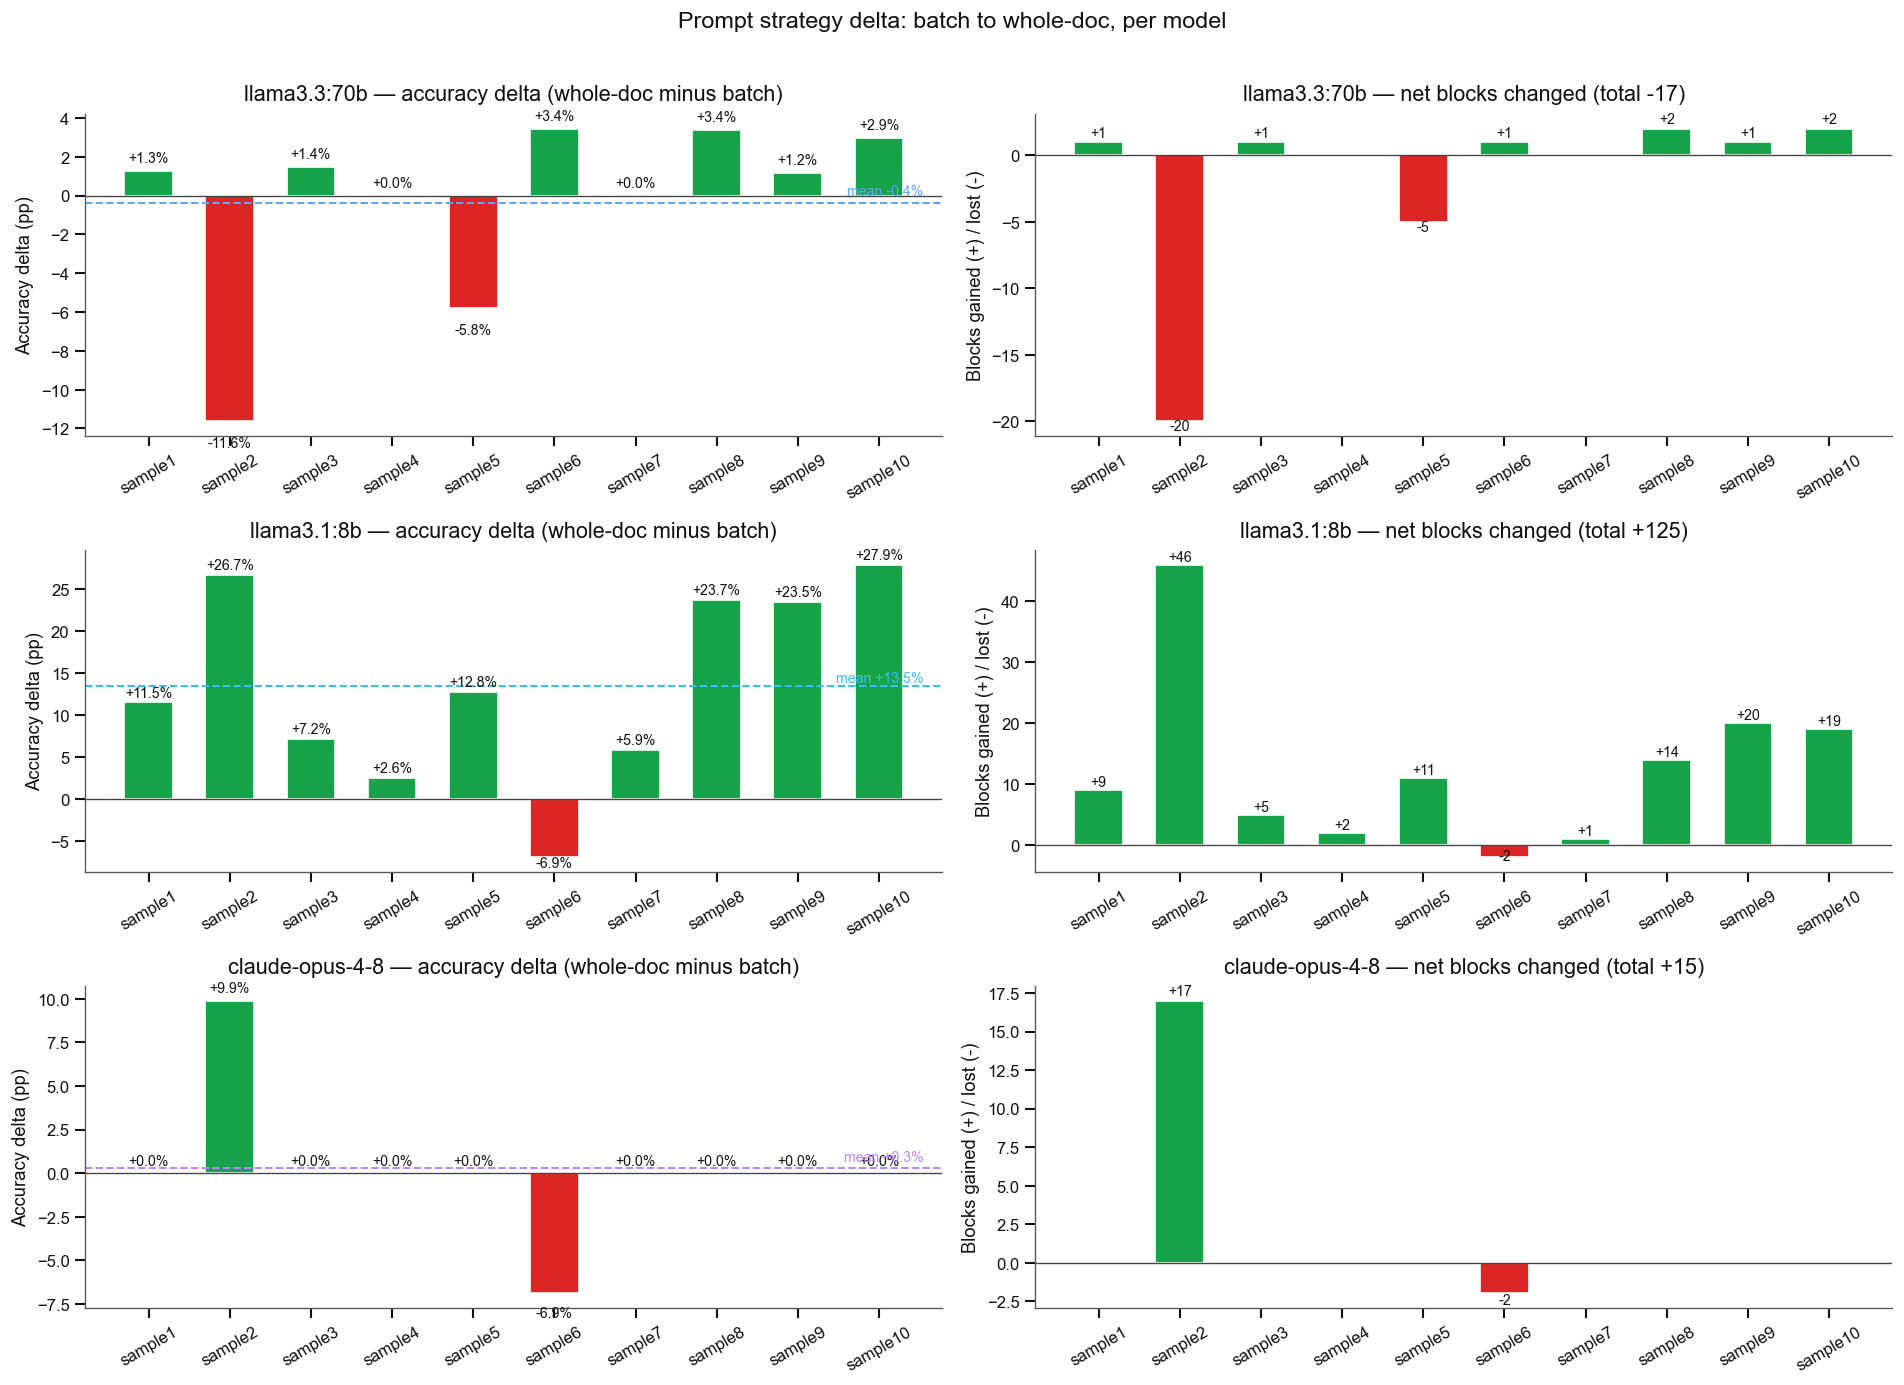


  llama3.3:70b  [10/10 samples compared]
  Sample           Batch   Whole-doc     Delta   Net blocks
  ---------------------------------------------------------
  sample1          97.4%       98.7%  +    1.3%  +         1
  sample2          90.7%       79.1%    -11.6%         -20
  sample3          98.6%      100.0%  +    1.4%  +         1
  sample4         100.0%      100.0%  +    0.0%  +         0
  sample5          91.9%       86.0%     -5.8%          -5
  sample6          62.1%       65.5%  +    3.4%  +         1
  sample7          94.1%       94.1%  +    0.0%  +         0
  sample8          96.6%      100.0%  +    3.4%  +         2
  sample9          98.8%      100.0%  +    1.2%  +         1
  sample10         95.6%       98.5%  +    2.9%  +         2
  ---------------------------------------------------------
  OVERALL          94.1%       91.8%     -2.3%         -17

  llama3.1:8b  [10/10 samples compared]
  Sample           Batch   Whole-doc     Delta   Net blocks
  ----------

In [7]:
comparable = [
    mname for mname in MODEL_FAMILIES
    if f"{mname} batch" in ACTIVE and f"{mname} whole-doc" in ACTIVE
]

if not comparable:
    print("No model families have both batch and whole-doc data.")
else:
    n_comp = len(comparable)
    fig, axes = plt.subplots(n_comp, 2, figsize=(16, 3.8 * n_comp), squeeze=False)
    merged_cache = {}

    for row_i, mname in enumerate(comparable):
        df_b  = ACTIVE[f"{mname} batch"][0]
        df_w  = ACTIVE[f"{mname} whole-doc"][0]
        cfg_w = VARIANTS[f"{mname} whole-doc"]

        merged = (
            df_b[["sample", "accuracy", "correct", "total"]]
            .rename(columns={"accuracy": "acc_b", "correct": "cor_b", "total": "tot"})
            .merge(
                df_w[["sample", "accuracy", "correct"]]
                .rename(columns={"accuracy": "acc_w", "correct": "cor_w"}),
                on="sample"
            )
        )
        merged["delta"]  = merged["acc_w"] - merged["acc_b"]
        merged["gained"] = merged["cor_w"] - merged["cor_b"]
        merged = merged.sort_values("sample", key=lambda s: s.map(_snum))
        merged_cache[mname] = merged

        ax = axes[row_i][0]
        bar_colors = ["#16a34a" if d >= 0 else "#dc2626" for d in merged["delta"]]
        bars = ax.bar(merged["sample"], merged["delta"] * 100,
                      color=bar_colors, edgecolor="white", width=0.6)
        for bar, d in zip(bars, merged["delta"] * 100):
            ypos = bar.get_height() + (0.3 if d >= 0 else -1.5)
            ax.text(bar.get_x() + bar.get_width() / 2, ypos,
                    f"{'+' if d >= 0 else ''}{d:.1f}%",
                    ha="center", va="bottom", fontsize=8.5)
        ax.axhline(0, color="#444", linewidth=0.8)
        avg = merged["delta"].mean() * 100
        ax.axhline(avg, color=cfg_w["color"], linestyle="--", linewidth=1.2)
        ax.text(len(merged) - 0.45, avg + 0.4,
                f"mean {avg:+.1f}%", ha="right", fontsize=8.5, color=cfg_w["color"])
        n_note = f" [{len(merged)}/10 samples]" if len(merged) < 10 else ""
        ax.set_ylabel("Accuracy delta (pp)")
        ax.set_title(f"{mname} — accuracy delta (whole-doc minus batch){n_note}", pad=8)
        ax.tick_params(axis="x", rotation=30)
        sns.despine(ax=ax)

        ax = axes[row_i][1]
        blk_colors = ["#16a34a" if g > 0 else ("#dc2626" if g < 0 else "#94a3b8")
                      for g in merged["gained"]]
        ax.bar(merged["sample"], merged["gained"],
               color=blk_colors, edgecolor="white", width=0.6)
        for xi, (_, r) in enumerate(merged.iterrows()):
            if r["gained"] != 0:
                ypos = r["gained"] + (0.15 if r["gained"] > 0 else -0.9)
                ax.text(xi, ypos,
                        f"{'+' if r['gained'] > 0 else ''}{int(r['gained'])}",
                        ha="center", va="bottom", fontsize=8.5)
        ax.axhline(0, color="#444", linewidth=0.8)
        net_total = int(merged["gained"].sum())
        ax.set_ylabel("Blocks gained (+) / lost (-)")
        ax.set_title(f"{mname} — net blocks changed (total {net_total:+d}){n_note}", pad=8)
        ax.tick_params(axis="x", rotation=30)
        sns.despine(ax=ax)

    plt.suptitle("Prompt strategy delta: batch to whole-doc, per model",
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    for mname in comparable:
        merged = merged_cache[mname]
        n_s = len(merged)
        print(f"\n  {mname}  [{n_s}/10 samples compared]")
        print(f"  {'Sample':<12}  {'Batch':>8}  {'Whole-doc':>10}  {'Delta':>8}  {'Net blocks':>11}")
        print("  " + "-" * 57)
        for _, r in merged.iterrows():
            print(f"  {r['sample']:<12}  {r['acc_b']*100:>7.1f}%"
                  f"  {r['acc_w']*100:>9.1f}%"
                  f"  {'+' if r['delta'] >= 0 else ''}{r['delta']*100:>7.1f}%"
                  f"  {'+' if r['gained'] >= 0 else ''}{int(r['gained']):>10}")
        print("  " + "-" * 57)
        tot = merged["tot"].sum()
        cb  = merged["cor_b"].sum()
        cw  = merged["cor_w"].sum()
        net = int(cw - cb)
        print(f"  {'OVERALL':<12}  {cb/tot*100:>7.1f}%"
              f"  {cw/tot*100:>9.1f}%"
              f"  {'+' if (cw-cb) >= 0 else ''}{(cw-cb)/tot*100:>7.1f}%"
              f"  {'+' if net >= 0 else ''}{net:>10}"
              + (f"  [{n_s}/10]" if n_s < 10 else ""))


---
## Section 6 — Block-level analysis

For each model family with both strategies, breaks down which specific blocks changed.

- Gained: whole-doc correct, batch wrong
- Lost: whole-doc wrong, batch correct

The confusion shift table reveals what kind of error whole-doc fixes or introduces.

In [8]:
def block_level_comparison(mname):
    tag_b = VARIANTS[f"{mname} batch"]["tag"]
    tag_w = VARIANTS[f"{mname} whole-doc"]["tag"]
    rows  = []
    for mp in SAMPLES:
        stem  = mp.stem.replace("_dmp", "")
        gold  = extract_gold(mp)
        pp_b  = LLM_DIR / f"{stem}_{tag_b}.json"
        pp_w  = LLM_DIR / f"{stem}_{tag_w}.json"
        if not (pp_b.exists() and pp_w.exists()): continue
        blks_b = json.loads(pp_b.read_text(encoding="utf-8"))
        blks_w = json.loads(pp_w.read_text(encoding="utf-8"))
        for i, (bb, bw) in enumerate(zip(blks_b, blks_w)):
            true_lbl = match(bb["text"], gold)
            if true_lbl is None: continue
            lb = bb.get("label", "answer.text")
            lw = bw.get("label", "answer.text")
            rows.append({
                "sample": stem, "block_id": i, "page": bb.get("page", "-"),
                "text": bb["text"][:80], "gold": true_lbl,
                "pred_batch": lb, "pred_whole": lw,
                "batch_ok": lb == true_lbl, "whole_ok": lw == true_lbl,
            })
    df     = pd.DataFrame(rows)
    gained = df[ df["whole_ok"] & ~df["batch_ok"]]
    lost   = df[~df["whole_ok"] &  df["batch_ok"]]
    return df, gained, lost

BLOCK_DATA = {}
for mname in comparable:
    df, gained, lost = block_level_comparison(mname)
    BLOCK_DATA[mname] = (df, gained, lost)
    print(f"{mname}:")
    print(f"  Total matched blocks : {len(df)}")
    print(f"  Both correct         : {(df['whole_ok'] & df['batch_ok']).sum()}")
    print(f"  Gained (whole-doc +) : {len(gained)}")
    print(f"  Lost   (whole-doc -) : {len(lost)}")
    print(f"  Both wrong           : {(~df['whole_ok'] & ~df['batch_ok']).sum()}")
    print(f"  Net change           : {len(gained)-len(lost):+d}")
    print()


llama3.3:70b:
  Total matched blocks : 726
  Both correct         : 671
  Gained (whole-doc +) : 9
  Lost   (whole-doc -) : 26
  Both wrong           : 20
  Net change           : -17



llama3.1:8b:
  Total matched blocks : 726
  Both correct         : 454
  Gained (whole-doc +) : 170
  Lost   (whole-doc -) : 45
  Both wrong           : 57
  Net change           : +125



claude-opus-4-8:
  Total matched blocks : 726
  Both correct         : 699
  Gained (whole-doc +) : 19
  Lost   (whole-doc -) : 4
  Both wrong           : 4
  Net change           : +15



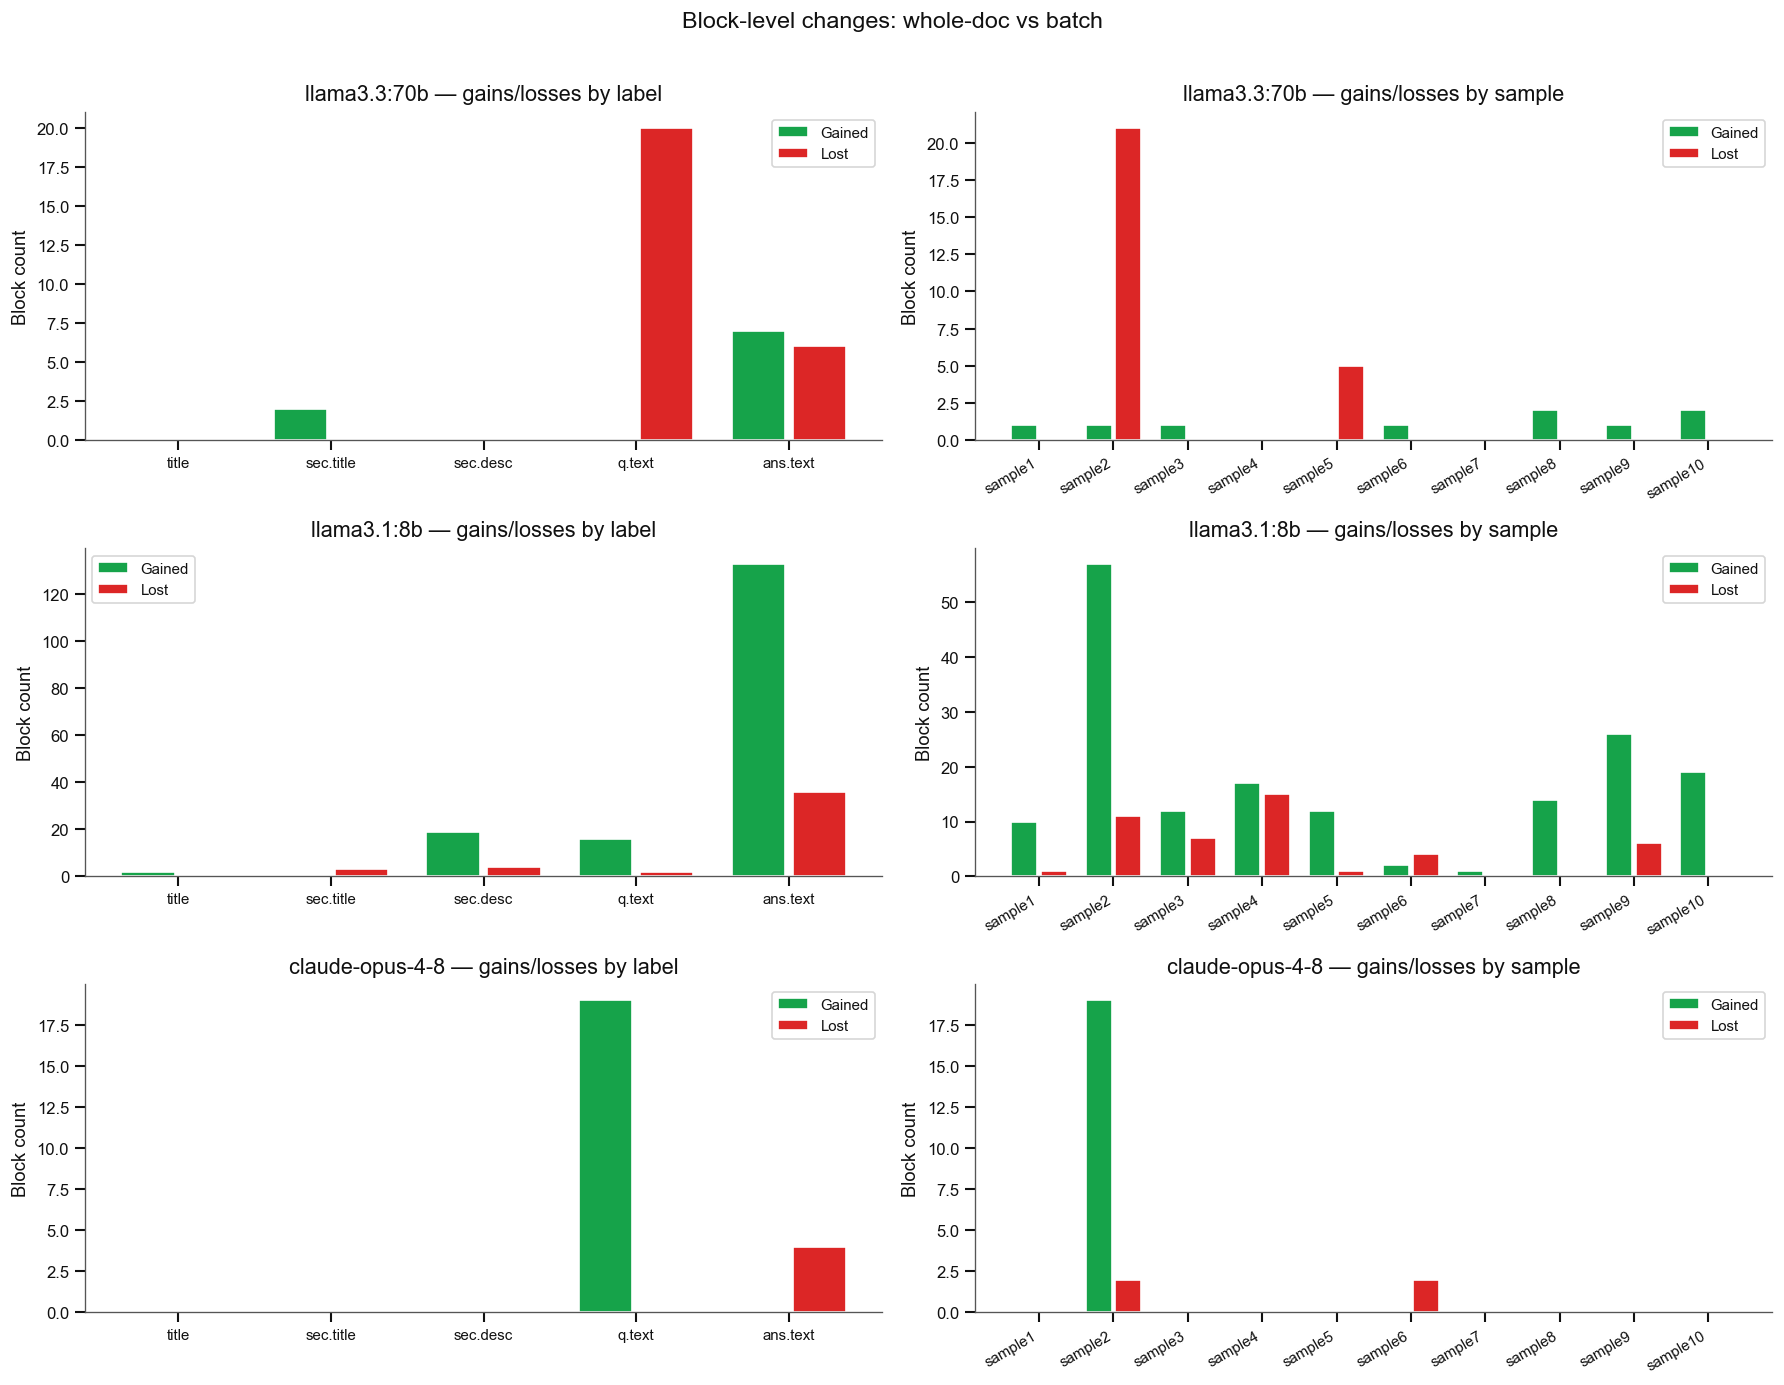


  llama3.3:70b
  Errors fixed by whole-doc (batch wrong, whole-doc correct):
               answer.text  misclassified as  section.description     x 5
             section.title  misclassified as  question.text           x 2
               answer.text  misclassified as  question.text           x 1
               answer.text  misclassified as  section.title           x 1
  Errors introduced by whole-doc (whole-doc wrong, batch correct):
             question.text  misclassified as  section.description     x 19
               answer.text  misclassified as  question.text           x 4
               answer.text  misclassified as  section.title           x 2
             question.text  misclassified as  section.title           x 1

  llama3.1:8b
  Errors fixed by whole-doc (batch wrong, whole-doc correct):
               answer.text  misclassified as  question.text           x 53
               answer.text  misclassified as  section.description     x 50
               answer.text  misclas

In [9]:
if BLOCK_DATA:
    n_m   = len(BLOCK_DATA)
    fig, axes = plt.subplots(n_m, 2, figsize=(15, 3.8 * n_m), squeeze=False)

    for row_i, (mname, (df, gained, lost)) in enumerate(BLOCK_DATA.items()):
        ax = axes[row_i][0]
        lbl_g = gained["gold"].value_counts().reindex(LABELS, fill_value=0)
        lbl_l = lost["gold"].value_counts().reindex(LABELS, fill_value=0)
        xi    = list(range(len(LABELS)))
        ax.bar([i - 0.2 for i in xi], lbl_g, 0.35,
               label="Gained", color="#16a34a", edgecolor="white")
        ax.bar([i + 0.2 for i in xi], lbl_l, 0.35,
               label="Lost",   color="#dc2626", edgecolor="white")
        ax.set_xticks(xi); ax.set_xticklabels(SHORT, fontsize=9)
        ax.set_ylabel("Block count")
        ax.set_title(f"{mname} — gains/losses by label", pad=7)
        ax.legend(fontsize=9); sns.despine(ax=ax)

        ax = axes[row_i][1]
        samp_g = gained["sample"].value_counts().reindex(SNAMES, fill_value=0)
        samp_l = lost["sample"].value_counts().reindex(SNAMES, fill_value=0)
        xi2    = list(range(len(SNAMES)))
        ax.bar([i - 0.2 for i in xi2], samp_g, 0.35,
               label="Gained", color="#16a34a", edgecolor="white")
        ax.bar([i + 0.2 for i in xi2], samp_l, 0.35,
               label="Lost",   color="#dc2626", edgecolor="white")
        ax.set_xticks(xi2)
        ax.set_xticklabels(SNAMES, rotation=30, ha="right", fontsize=9)
        ax.set_ylabel("Block count")
        ax.set_title(f"{mname} — gains/losses by sample", pad=7)
        ax.legend(fontsize=9); sns.despine(ax=ax)

    plt.suptitle("Block-level changes: whole-doc vs batch", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    for mname, (_, gained, lost) in BLOCK_DATA.items():
        print(f"\n{'='*60}")
        print(f"  {mname}")
        print(f"{'='*60}")
        if len(gained):
            print("  Errors fixed by whole-doc (batch wrong, whole-doc correct):")
            tbl = (gained.groupby(["gold", "pred_batch"]).size()
                   .reset_index(name="count")
                   .sort_values("count", ascending=False))
            for _, r in tbl.iterrows():
                print(f"    {r['gold']:>22}  misclassified as  {r['pred_batch']:<22}  x {r['count']}")
        if len(lost):
            print("  Errors introduced by whole-doc (whole-doc wrong, batch correct):")
            tbl = (lost.groupby(["gold", "pred_whole"]).size()
                   .reset_index(name="count")
                   .sort_values("count", ascending=False))
            for _, r in tbl.iterrows():
                print(f"    {r['gold']:>22}  misclassified as  {r['pred_whole']:<22}  x {r['count']}")


In [10]:
pd.set_option("display.max_colwidth", 80)
for mname, (_, gained, lost) in BLOCK_DATA.items():
    print(f"\n{'='*70}")
    print(f"  {mname}  —  {len(gained)} gained, {len(lost)} lost")
    print(f"{'='*70}")
    if len(gained):
        print("  GAINED (whole-doc correct, batch wrong):")
        display(gained[["sample", "page", "gold", "pred_batch", "pred_whole", "text"]]
                .reset_index(drop=True))
    if len(lost):
        print("  LOST (whole-doc wrong, batch correct):")
        display(lost[["sample", "page", "gold", "pred_batch", "pred_whole", "text"]]
                .reset_index(drop=True))



  llama3.3:70b  —  9 gained, 26 lost
  GAINED (whole-doc correct, batch wrong):


,sample,page,gold,pred_batch,pred_whole,text
0,sample1,1,answer.text,question.text,answer.text,The following data will be created as a result of this project:
1,sample2,3,answer.text,section.description,answer.text,"principles of this Statement, data sharing should make digital research data..."
2,sample3,2,section.title,question.text,section.title,Policies for access and sharing and appropriate protection and privacy
3,sample6,1,answer.text,section.title,answer.text,"1. Types of data. The bulk of the data generated in this project will be 1, ..."
4,sample8,2,answer.text,section.description,answer.text,"In keeping with standard ethical practices, it is expected that subsequent u..."
5,sample8,2,answer.text,section.description,answer.text,source.
6,sample9,3,section.title,question.text,section.title,"Policies and provisions for re-use, re-distribution, and production of deriv..."
7,sample10,2,answer.text,section.description,answer.text,It is understood that the NSF Engineering Directorate requires data to be ma...
8,sample10,2,answer.text,section.description,answer.text,"of three years after conclusion of the award or public release, whichever is..."


  LOST (whole-doc wrong, batch correct):


,sample,page,gold,pred_batch,pred_whole,text
0,sample2,1,question.text,question.text,section.description,Content and Format. A statement of plans for data and metadata content and f...
1,sample2,2,question.text,question.text,section.description,the anticipated means for sharing and rationale for any restrictions on who ...
2,sample2,2,question.text,question.text,section.description,and under what conditions;
3,sample2,2,question.text,question.text,section.description,a timeline for sharing and preservation that addresses both the minimum leng...
4,sample2,2,question.text,question.text,section.description,will be available and any anticipated delay to data access after research fi...
5,sample2,2,question.text,question.text,section.description,"any special requirements for data sharing, for example, proprietary software..."
6,sample2,2,question.text,question.text,section.description,"or interpret data, applicable policies, provisions, and licenses for re-use ..."
7,sample2,2,question.text,question.text,section.description,"for the production of derivatives, including guidance for how data and data ..."
8,sample2,2,question.text,question.text,section.description,cited;
9,sample2,2,question.text,question.text,section.description,"any resources and capabilities (equipment, connections, systems, software, e..."



  llama3.1:8b  —  170 gained, 45 lost
  GAINED (whole-doc correct, batch wrong):


...

,sample,page,gold,pred_batch,pred_whole,text
0,sample1,1,question.text,question.text,section.title,"B. Scientific data that will be preserved and shared, and the rationale for ..."
1,sample2,1,answer.text,answer.text,question.text,"Roles & Responsibilities. For the proposed research, Director Samuel Stupp w..."
2,sample2,1,question.text,question.text,section.title,"Data Types and Sources. A brief, high-level description of the data to be ge..."
3,sample2,2,section.title,section.title,question.text,preservation;
4,sample2,3,answer.text,answer.text,section.title,"retention, and data management."
5,sample2,3,section.title,section.title,section.description,2. Data used in publications
6,sample2,4,section.description,section.description,question.text,DMPs should consult and reference available information about data managemen...
7,sample2,4,section.description,section.description,question.text,"used in the course of the proposed research. In particular, DMPs that explic..."
8,sample2,4,section.description,section.description,question.text,users should be accompanied by written approval from that facility. In deter...
9,sample2,4,section.description,section.description,question.text,"available for data management at Office of Science User Facilities, research..."



  claude-opus-4-8  —  19 gained, 4 lost
  GAINED (whole-doc correct, batch wrong):


,sample,page,gold,pred_batch,pred_whole,text
0,sample2,2,question.text,section.description,question.text,"This should include, where appropriate:"
1,sample2,2,question.text,section.description,question.text,the anticipated means for sharing and rationale for any restrictions on who ...
2,sample2,2,question.text,section.description,question.text,and under what conditions;
3,sample2,2,question.text,section.description,question.text,a timeline for sharing and preservation that addresses both the minimum leng...
4,sample2,2,question.text,section.description,question.text,will be available and any anticipated delay to data access after research fi...
5,sample2,2,question.text,section.description,question.text,"any special requirements for data sharing, for example, proprietary software..."
6,sample2,2,question.text,section.description,question.text,"or interpret data, applicable policies, provisions, and licenses for re-use ..."
7,sample2,2,question.text,section.description,question.text,"for the production of derivatives, including guidance for how data and data ..."
8,sample2,2,question.text,section.description,question.text,cited;
9,sample2,2,question.text,section.description,question.text,"any resources and capabilities (equipment, connections, systems, software, e..."


  LOST (whole-doc wrong, batch correct):


,sample,page,gold,pred_batch,pred_whole,text
0,sample2,1,answer.text,answer.text,question.text,"Roles & Responsibilities. For the proposed research, Director Samuel Stupp w..."
1,sample2,4,answer.text,answer.text,question.text,"Data Volume. Generally, the volume of data generated by CBES researchers sho..."
2,sample6,1,answer.text,answer.text,section.title,"1. Types of data. The bulk of the data generated in this project will be 1, ..."
3,sample6,1,answer.text,answer.text,section.title,3. Policies for access and sharing. Interested parties will be able to reque...


---
## Section 7 — Cross-model agreement

For each matched block (aligned to gold), counts how many of the active variants
labeled it correctly.

- All correct: easy blocks; any model handles them
- 1–2 correct: ambiguous blocks; model choice matters
- All wrong: genuinely hard blocks; may need prompt or label refinement

In [11]:
tag_list   = [(n, VARIANTS[n]["tag"]) for n in ACTIVE]
cross_rows = []

for mp in SAMPLES:
    stem  = mp.stem.replace("_dmp", "")
    gold  = extract_gold(mp)
    bsets = {}
    for name, tag in tag_list:
        pp = LLM_DIR / f"{stem}_{tag}.json"
        if pp.exists():
            bsets[name] = json.loads(pp.read_text(encoding="utf-8"))
    if not bsets: continue
    ref_name = next(iter(bsets))
    for idx, b in enumerate(bsets[ref_name]):
        true_lbl = match(b["text"], gold)
        if true_lbl is None: continue
        preds     = {n: bsets[n][idx].get("label", "answer.text")
                     for n in bsets if idx < len(bsets[n])}
        n_correct = sum(1 for p in preds.values() if p == true_lbl)
        row = {"sample": stem, "text": b["text"][:100],
               "page": b.get("page", "-"), "true": true_lbl, "n_correct": n_correct}
        for n, _ in tag_list:
            row[f"pred_{n.replace(' ', '_')}"] = preds.get(n, "--")
        cross_rows.append(row)

df_cross = pd.DataFrame(cross_rows)
total    = len(df_cross)
print(f"Cross-model agreement  ({n_v} variants, {total} matched blocks)\n")
for n in range(n_v, -1, -1):
    lbl = {n_v: "all correct", 0: "all wrong"}.get(n, f"{n} correct")
    cnt = (df_cross["n_correct"] == n).sum()
    pct = cnt / total * 100
    bar = chr(9608) * int(pct / 2)
    print(f"  {lbl:<14} {cnt:>4}  ({pct:>5.1f}%)  {bar}")
print(f"\nBlocks all variants got wrong: {(df_cross['n_correct'] == 0).sum()}")


Cross-model agreement  (6 variants, 726 matched blocks)

  all correct     438  ( 60.3%)  ██████████████████████████████
  5 correct       196  ( 27.0%)  █████████████
  4 correct        56  (  7.7%)  ███
  3 correct        24  (  3.3%)  █
  2 correct         6  (  0.8%)  
  1 correct         5  (  0.7%)  
  all wrong         1  (  0.1%)  

Blocks all variants got wrong: 1


C:\Users\Nahid\AppData\Local\Temp\ipykernel_72164\2963406761.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_lbl2, rotation=30, ha="right")


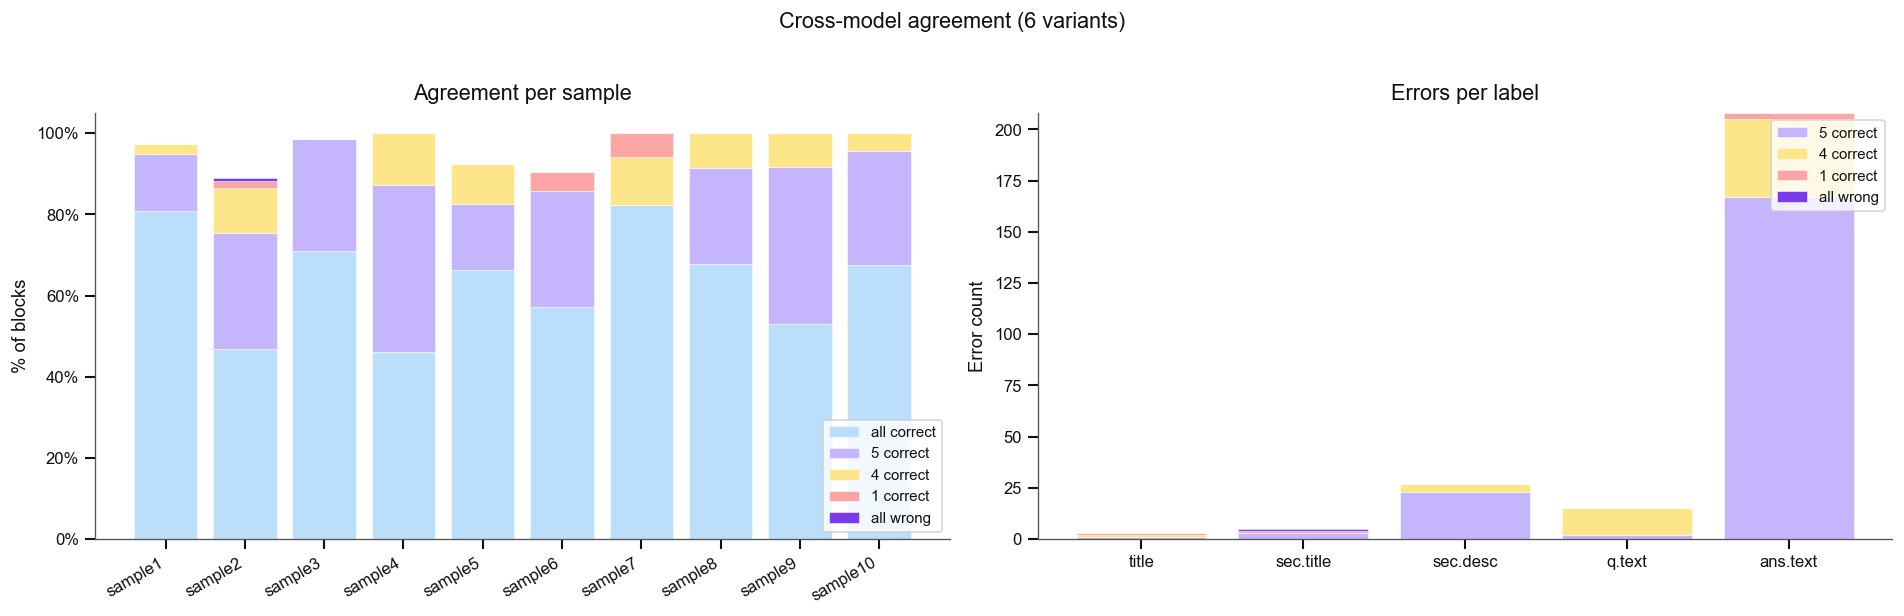

In [12]:
palette = ["#bbdefb", "#c4b5fd", "#fde68a", "#fca5a5", "#7c3aed"]
levels  = [n for n in [n_v, n_v-1, n_v-2, 1, 0] if n >= 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
x_lbl2  = sorted(df_cross["sample"].unique(), key=_snum)
bottoms = {s: 0 for s in x_lbl2}
for n, color in zip(levels, palette):
    lbl  = {n_v: "all correct", 0: "all wrong"}.get(n, f"{n} correct")
    vals = [(df_cross[df_cross["sample"] == s]["n_correct"] == n).sum() /
            max(len(df_cross[df_cross["sample"] == s]), 1) * 100 for s in x_lbl2]
    ax.bar(x_lbl2, vals, bottom=[bottoms[s] for s in x_lbl2],
           label=lbl, color=color, edgecolor="white", linewidth=0.3)
    for s, v in zip(x_lbl2, vals): bottoms[s] += v
ax.set_ylim(0, 105)
ax.set_ylabel("% of blocks")
ax.set_title("Agreement per sample", pad=8)
ax.set_xticklabels(x_lbl2, rotation=30, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.legend(loc="lower right", fontsize=9)
sns.despine(ax=ax)

ax = axes[1]
btm = [0] * len(LABELS)
for n, color in list(zip(levels, palette))[1:]:
    lbl  = {0: "all wrong"}.get(n, f"{n} correct")
    vals = [(df_cross[df_cross["true"] == l]["n_correct"] == n).sum() for l in LABELS]
    ax.bar(range(len(LABELS)), vals, bottom=btm, label=lbl,
           color=color, edgecolor="white", linewidth=0.3)
    btm = [b + v for b, v in zip(btm, vals)]
ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(SHORT, fontsize=10)
ax.set_ylabel("Error count")
ax.set_title("Errors per label", pad=8)
ax.legend(loc="upper right", fontsize=9)
sns.despine(ax=ax)

plt.suptitle(f"Cross-model agreement ({n_v} variants)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## Section 8 — Error drill-down

Filterable view of block-level errors. Edit the variables below to inspect any
combination of variant, true label, predicted label, or sample.

Valid values for FILTER_VARIANT: any key from ACTIVE (e.g. `"claude-opus-4-8 whole-doc"`,
`"llama3.3:70b batch"`). Set to `""` to view errors across all variants.

In [13]:
FILTER_VARIANT = "claude-opus-4-8 whole-doc"  # variant name or "" for all
FILTER_TRUE    = ""                             # label name or "" for all
FILTER_PRED    = ""                             # label name or "" for all
FILTER_SAMPLE  = ""                             # e.g. "sample2" or "" for all
ONLY_ERRORS    = True

pred_col  = f"pred_{FILTER_VARIANT.replace(' ', '_')}" if FILTER_VARIANT else None
pred_cols = [c for c in df_cross.columns if c.startswith("pred_")]

mask = pd.Series([True] * len(df_cross), index=df_cross.index)
if ONLY_ERRORS:
    if pred_col and pred_col in df_cross.columns:
        mask &= df_cross[pred_col] != df_cross["true"]
    else:
        mask &= df_cross["n_correct"] < n_v
if FILTER_TRUE:   mask &= df_cross["true"]   == FILTER_TRUE
if FILTER_SAMPLE: mask &= df_cross["sample"] == FILTER_SAMPLE
if FILTER_PRED and pred_col and pred_col in df_cross.columns:
    mask &= df_cross[pred_col] == FILTER_PRED

subset = df_cross[mask].reset_index(drop=True)
print(f"variant={FILTER_VARIANT or 'all'}  true={FILTER_TRUE or 'any'}  "
      f"pred={FILTER_PRED or 'any'}  sample={FILTER_SAMPLE or 'all'}")
print(f"Matching blocks: {len(subset)}\n")
if not subset.empty:
    pd.set_option("display.max_colwidth", 90)
    display(subset[["sample", "page", "true", "n_correct"] + pred_cols + ["text"]])


variant=claude-opus-4-8 whole-doc  true=any  pred=any  sample=all
Matching blocks: 8



,sample,page,true,n_correct,pred_llama3.3:70b_batch,pred_llama3.3:70b_whole-doc,pred_llama3.1:8b_batch,pred_llama3.1:8b_whole-doc,pred_claude-opus-4-8_batch,pred_claude-opus-4-8_whole-doc,text
0,sample2,1,answer.text,4,answer.text,answer.text,answer.text,question.text,answer.text,question.text,"Roles & Responsibilities. For the proposed research, Director Samuel Stupp with help f..."
1,sample2,2,section.title,1,question.text,section.description,section.title,question.text,section.description,question.text,preservation;
2,sample2,4,answer.text,1,answer.text,question.text,section.title,section.title,question.text,question.text,Data Repositories. Senior investigators typically archive relevant data using their ow...
3,sample2,4,answer.text,1,section.title,section.title,section.title,section.title,answer.text,question.text,"Data Volume. Generally, the volume of data generated by CBES researchers should not pr..."
4,sample2,5,section.title,0,section.description,section.description,answer.text,section.description,section.description,section.description,data.
5,sample6,1,answer.text,2,section.title,answer.text,section.title,section.title,answer.text,section.title,"1. Types of data. The bulk of the data generated in this project will be 1, 2, 3, and 4"
6,sample6,1,answer.text,1,section.title,section.title,section.title,section.title,answer.text,section.title,3. Policies for access and sharing. Interested parties will be able to request data an...
7,sample7,1,title,1,section.title,section.title,section.title,title,section.title,section.title,Resource/Data Sharing Plan


---
## Section 9 — Summary

In [14]:
print("=" * 70)
print("  Prompt Strategy Comparison — All Models")
print("  10 DMP samples · 5 labels · block-level evaluation")
print("=" * 70)
print()

print(f"  {'Variant':<32}  {'Accuracy':>9}  {'q.text F1':>10}  {'sec.desc F1':>12}")
print("  " + "-" * 70)
best_acc = max(
    ACTIVE[n][0]["correct"].sum() / ACTIVE[n][0]["total"].sum()
    for n in ACTIVE
)
for name, (df, conf) in ACTIVE.items():
    tc, tn = int(df["correct"].sum()), int(df["total"].sum())
    f1_qt  = _f1(conf, "question.text")       * 100
    f1_sd  = _f1(conf, "section.description") * 100
    marker = "  <-- best" if tc/tn == best_acc else ""
    print(f"  {name:<32}  {tc/tn*100:>8.1f}%  {f1_qt:>9.1f}%  {f1_sd:>11.1f}%{marker}")

print()
print("  Prompt strategy effect (batch to whole-doc):")
for mname in comparable:
    df_b, conf_b = ACTIVE[f"{mname} batch"]
    df_w, conf_w = ACTIVE[f"{mname} whole-doc"]
    _, gained, lost = BLOCK_DATA[mname]
    acc_b = df_b["correct"].sum() / df_b["total"].sum() * 100
    acc_w = df_w["correct"].sum() / df_w["total"].sum() * 100
    dqt   = (_f1(conf_w, "question.text")       - _f1(conf_b, "question.text"))       * 100
    dsd   = (_f1(conf_w, "section.description") - _f1(conf_b, "section.description")) * 100
    print(f"    {mname:<20}  acc {acc_b:.1f}% -> {acc_w:.1f}% ({acc_w-acc_b:+.1f}pp)"
          f"  q.text {dqt:+.1f}pp  sec.desc {dsd:+.1f}pp  net blocks {len(gained)-len(lost):+d}")

print()
print("  Cross-model agreement:")
total = len(df_cross)
for n in [n_v, n_v-1]:
    lbl = "all correct" if n == n_v else f"{n}/{n_v} correct"
    cnt = (df_cross["n_correct"] == n).sum()
    print(f"    {lbl:<18}  {cnt:>4}  ({cnt/total*100:.1f}%)")
cnt0 = (df_cross["n_correct"] == 0).sum()
print(f"    {'all wrong':<18}  {cnt0:>4}  ({cnt0/total*100:.1f}%)")

print()
print("=" * 70)


  Prompt Strategy Comparison — All Models
  10 DMP samples · 5 labels · block-level evaluation

  Variant                            Accuracy   q.text F1   sec.desc F1
  ----------------------------------------------------------------------
  llama3.3:70b batch                    94.1%       70.7%         87.7%
  llama3.3:70b whole-doc                91.8%       29.0%         78.6%
  llama3.1:8b batch                     67.3%       26.1%         40.5%
  llama3.1:8b whole-doc                 84.2%       48.6%         75.4%
  claude-opus-4-8 batch                 94.9%       62.0%         84.4%
  claude-opus-4-8 whole-doc             96.9%       88.2%         99.1%  <-- best

  Prompt strategy effect (batch to whole-doc):
    llama3.3:70b          acc 94.1% -> 91.8% (-2.3pp)  q.text -41.7pp  sec.desc -9.1pp  net blocks -17
    llama3.1:8b           acc 67.3% -> 84.2% (+16.9pp)  q.text +22.4pp  sec.desc +34.9pp  net blocks +125
    claude-opus-4-8       acc 94.9% -> 96.9% (+2.0pp)  q.tex